<a href="https://colab.research.google.com/github/olawaleaboderin/AVCAD/blob/main/Exercise9_ClusterAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

**Preprocessing Stage**


In [2]:
# ── Load dataset ─────────────────────────────────────────────
df = pd.read_csv(
    'https://raw.githubusercontent.com/olawaleaboderin/greends-avcad-2026/main/examples/EFIplus_medit.zip',
    sep=";"
)


In [3]:
print("Total columns:", len(df.columns))
print("\nAll column names:")
for i, col in enumerate(df.columns):
    print(f"  {i:>3}  {col}")

Total columns: 164

All column names:
    0  Site_code
    1  Latitude
    2  Longitude
    3  Country
    4  Catchment_name
    5  Galiza
    6  Subsample
    7  Calib_EFI_Medit
    8  Calib_connect
    9  Calib_hydrol
   10  Calib_morphol
   11  Calib_wqual
   12  Geomorph1
   13  Geomorph2
   14  Geomorph3
   15  Water_source_type
   16  Flow_regime
   17  Altitude
   18  Geological_typology
   19  Actual_river_slope
   20  Natural_sediment
   21  Elevation_mean_catch
   22  prec_ann_catch
   23  temp_ann
   24  temp_jan
   25  temp_jul
   26  Barriers_catchment_down
   27  Barriers_river_segment_up
   28  Barriers_river_segment_down
   29  Barriers_number_river_segment_up
   30  Barriers_number_river_segment_down
   31  Barriers_distance_river_segment_up
   32  Barriers_distance_river_segment_down
   33  Impoundment
   34  Hydropeaking
   35  Water_abstraction
   36  Hydro_mod
   37  Temperature_impact
   38  Velocity_increase
   39  Reservoir_flushing
   40  Sedimentation
   41  C

In [4]:
# ── Environmental variables ──────
predictors = ['Altitude', 'Actual_river_slope', 'Elevation_mean_catch',
              'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul']

In [5]:
# ── Filter: Douro and Tejo basins only ───────────────────────
df_basins = df[df['Catchment_name'].isin(['Douro', 'Tejo'])].copy()
print("Sites in Douro and Tejo:")
print(df_basins['Catchment_name'].value_counts())


Sites in Douro and Tejo:
Catchment_name
Tejo     509
Douro    401
Name: count, dtype: int64


In [6]:
# ── Select predictors and drop NAs ───────────────────────────
df_cluster = df_basins[predictors + ['Catchment_name']].dropna()
X = df_cluster[predictors]
print(f"\nFinal dataset: {X.shape[0]} sites × {X.shape[1]} variables")



Final dataset: 888 sites × 7 variables


In [7]:
# ── Standardise (essential — variables are on different scales)
scaler      = StandardScaler()
X_scaled    = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=predictors, index=X.index)

## **Question 1:** Run agglomerative cluster analysis using different linkage methods based on quantitative environmental variables (see previous exercise), using sites from the Douro and Tejo basins.

**AI prompt used:** *Run agglomerative hierarchical cluster analysis on the seven quantitative environmental variables (Altitude, Actual_river_slope, Elevation_mean_catch, prec_ann_catch, temp_ann, temp_jan, temp_jul) using four different linkage methods: ward, complete, average and single. Plot all four dendrograms in a single figure for comparison and print the number of clusters detected at a fixed distance threshold for each method.*


Agglomerative Cluster Analysis


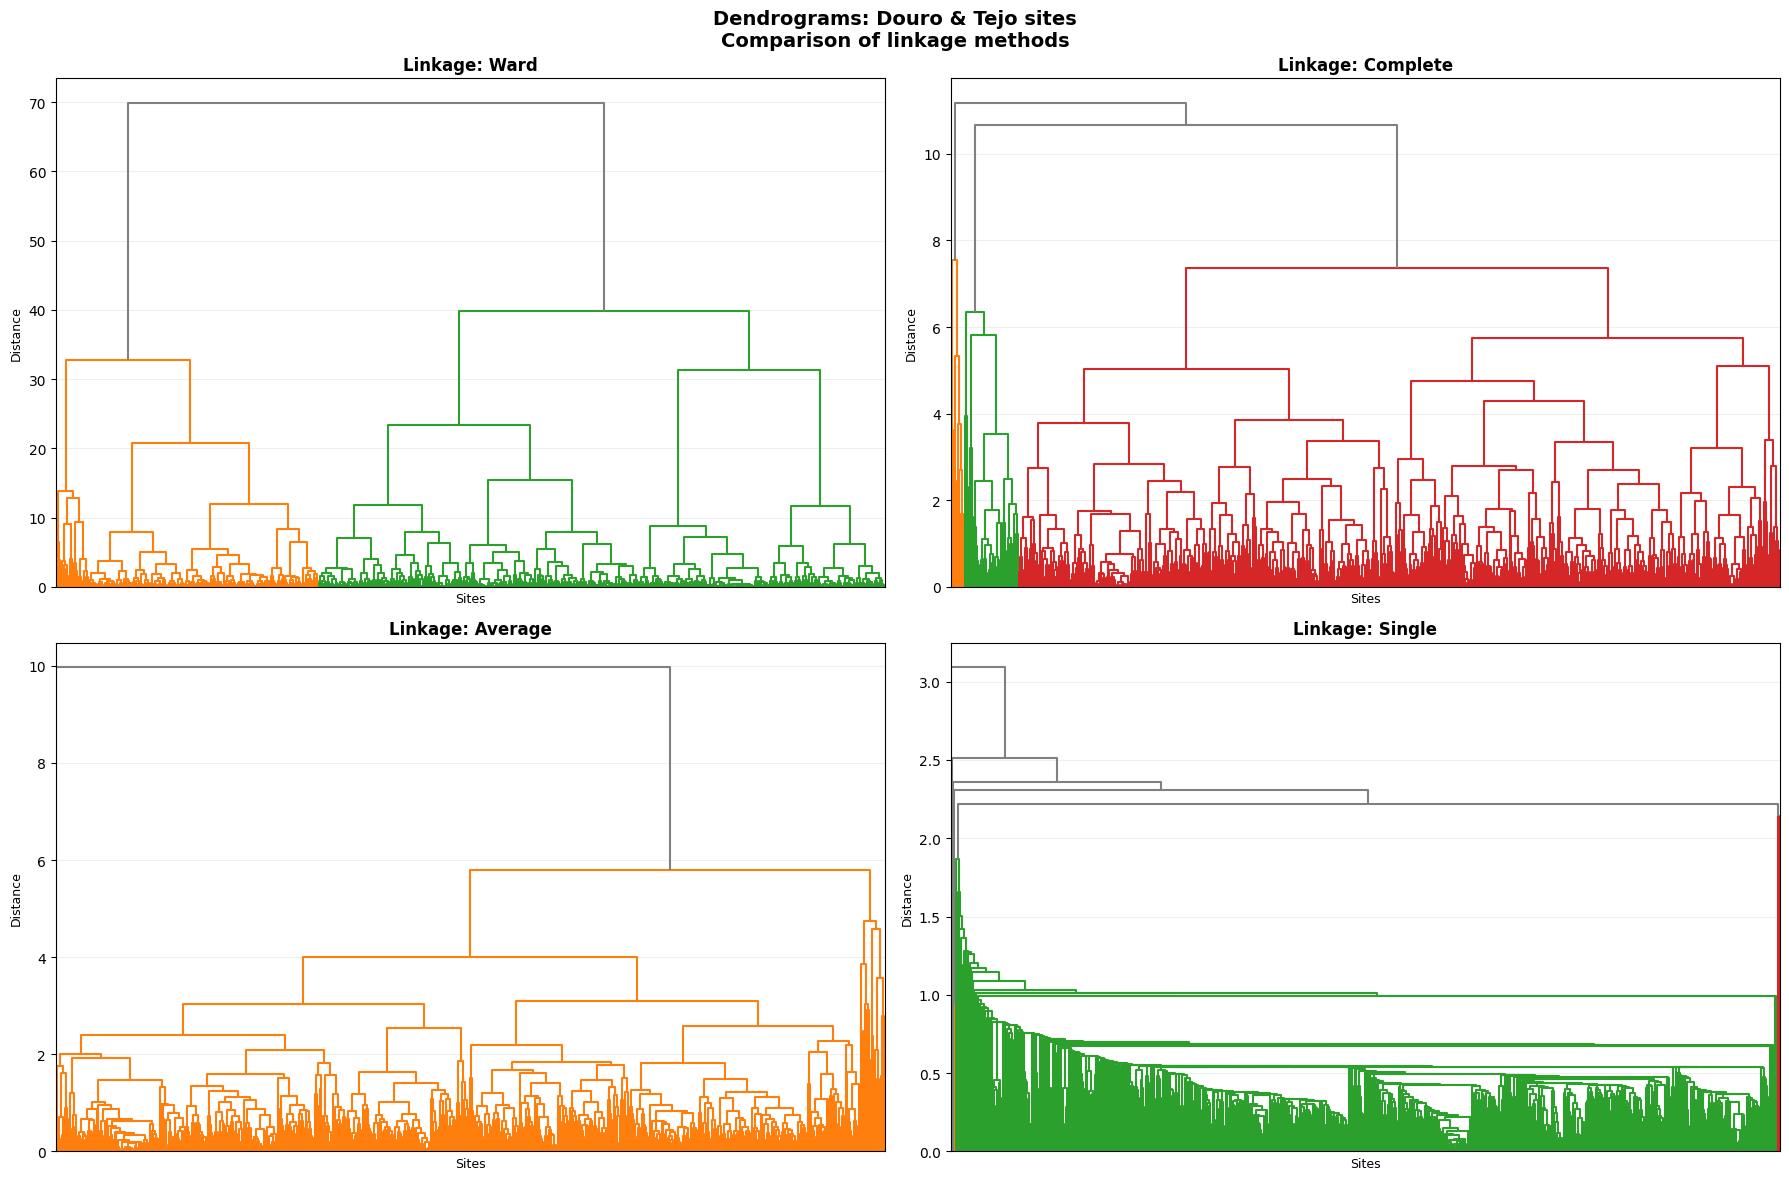


Number of clusters at distance threshold (t=5) per linkage method:
  ward      : 32 clusters
  complete  : 11 clusters
  average   : 3 clusters
  single    : 1 clusters


In [8]:
print("\n" + "="*60)
print("Agglomerative Cluster Analysis")
print("="*60)

linkage_methods = ['ward', 'complete', 'average', 'single']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()
fig.suptitle('Dendrograms: Douro & Tejo sites\n'
             'Comparison of linkage methods',
             fontsize=14, fontweight='bold')

for i, method in enumerate(linkage_methods):
    Z = linkage(X_scaled, method=method, metric='euclidean')
    ax = axes[i]
    dendrogram(
        Z,
        ax=ax,
        no_labels=True,
        color_threshold=0.7 * max(Z[:, 2]),
        above_threshold_color='grey'
    )
    ax.set_title(f'Linkage: {method.capitalize()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sites', fontsize=9)
    ax.set_ylabel('Distance', fontsize=9)
    ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

# Cluster count comparison at fixed threshold
print("\nNumber of clusters at distance threshold (t=5) per linkage method:")
for method in linkage_methods:
    Z = linkage(X_scaled, method=method, metric='euclidean')
    n_clusters = len(set(fcluster(Z, t=5, criterion='distance')))
    print(f"  {method:<10}: {n_clusters} clusters")

Four linkage methods were applied to cluster the Douro and Tejo sites based on their environmental characteristics. The **Ward linkage** produced the most balanced and interpretable dendrogram, clearly separating sites into two main groups at a high distance (cutoff = 40), suggesting two distinct environmental clusters exist across the two basins. The **Complete linkage** also produced a relatively balanced structure but with more subdivisions within clusters. The **Average linkage** identified 3 clusters at the fixed threshold, offering a compromise between Ward and Complete. The **Single linkage** produced only 1 cluster at the same threshold, showing the classic "chaining effect" where sites are linked one by one rather than forming compact groups, making it the least useful method for this dataset. Based on this result, Ward and Complete linkage are the most informative methods for this dataset, as they produce cleaner and more interpretable cluster structures.

## **Question 2:** Plot a heatmap and a dendrogram by clustering the rows (sites) using average linkage

**AI prompt used:** *Using the filtered Douro and Tejo sites from the EFIplus_medit dataset, plot a heatmap with a dendrogram clustering the rows (sites) using average linkage and euclidean distance. Standardise the variables before clustering. Colour the row labels by basin (Douro and Tejo) and include a legend. Use a RdYlBu_r colour palette for the heatmap.*


Heatmap + Dendrogram (sites, average linkage)


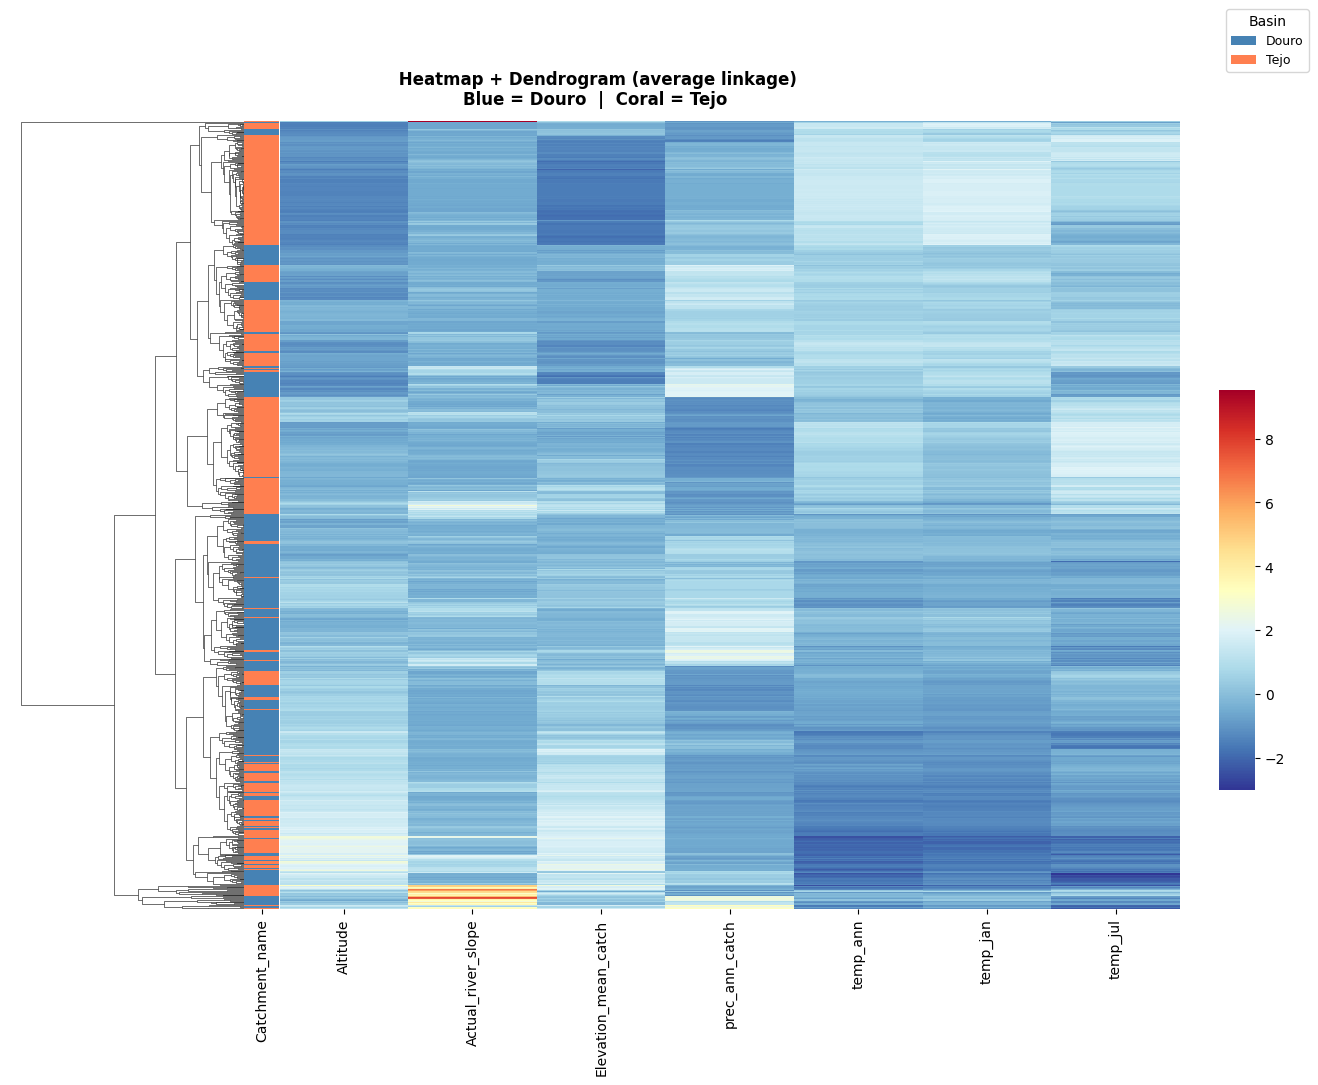

In [12]:

print("\n" + "="*60)
print("Heatmap + Dendrogram (sites, average linkage)")
print("="*60)

# Colour rows by basin
basin_colors = {'Douro': 'steelblue', 'Tejo': 'coral'}
row_colors   = df_cluster['Catchment_name'].map(basin_colors)

g = sns.clustermap(
    X_scaled_df,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=False,
    row_colors=row_colors,
    cmap='RdYlBu_r',
    figsize=(12, 10),
    xticklabels=True,
    yticklabels=False,
    dendrogram_ratio=(0.2, 0.02),
    cbar_pos=(1.02, 0.3, 0.03, 0.4)
)

g.figure.suptitle(' Heatmap + Dendrogram (average linkage)\n'
                  'Blue = Douro  |  Coral = Tejo',
                  y=1.02, fontsize=12, fontweight='bold')

legend_elements = [Patch(facecolor='steelblue', label='Douro'),
                   Patch(facecolor='coral',     label='Tejo')]
g.ax_heatmap.legend(handles=legend_elements,
                    loc='upper right',
                    bbox_to_anchor=(1.15, 1.15),
                    title='Basin', fontsize=9)
plt.show()

The heatmap with average linkage dendrogram reveals clear patterns in how sites group based on their environmental conditions. Three broad clusters of sites emerge from the dendrogram. The top cluster contains sites characterised by relatively higher altitude and river slope values (lighter blue) combined with lower temperatures. The middle cluster shows intermediate environmental conditions across all variables. The bottom cluster, which contains a notable concentration of Tejo sites (orange), is characterised by very low altitude and slope values but higher temperature values, representing lowland warmer sites. Notably, Douro and Tejo sites do not separate completely into distinct clusters, both basins contain sites that overlap in environmental space, suggesting that basin identity alone does not determine the environmental conditions experienced at each site.

## **Question 3:** Plot a dendrogram that clusters the environmental variables instead (columns) using average linkage.

**AI prompt used:** *Using the same standardised environmental variables from the Douro and Tejo sites, transpose the dataframe so that variables become rows and plot a dendrogram clustering the environmental variables using average linkage and euclidean distance. Label each variable clearly on the dendrogram*


Dendrogram: clustering variables (average linkage)
Transposed shape: (7, 888) (7 variables × 888 sites)


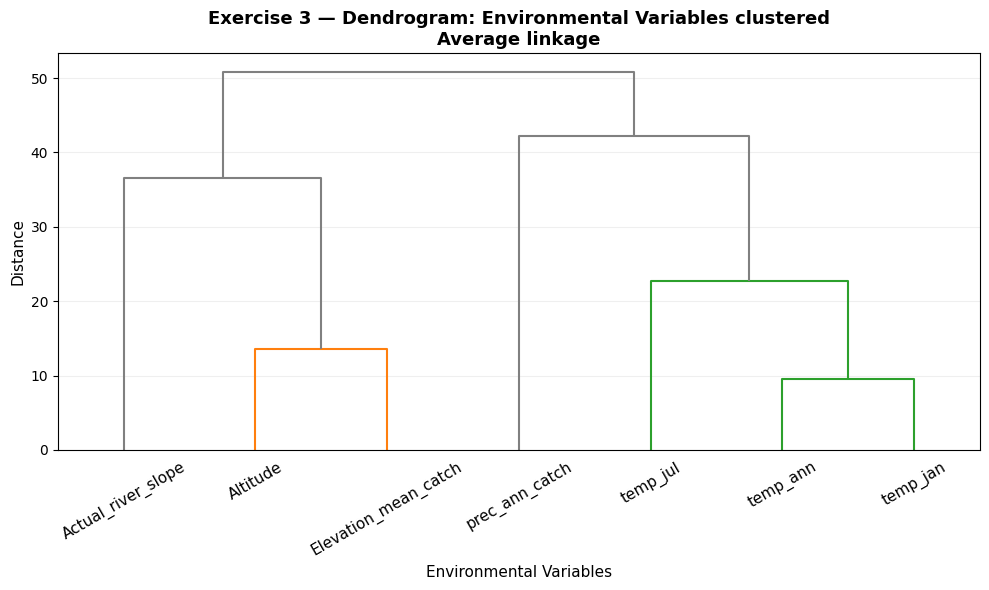

In [13]:
print("\n" + "="*60)
print("Dendrogram: clustering variables (average linkage)")
print("="*60)

# Transpose so variables become rows (as instructed in the NOTE)
X_transposed = X_scaled_df.T
print(f"Transposed shape: {X_transposed.shape} "
      f"({X_transposed.shape[0]} variables × {X_transposed.shape[1]} sites)")

# Linkage on transposed data
Z_cols = linkage(X_transposed, method='average', metric='euclidean')

fig, ax = plt.subplots(figsize=(10, 6))
dendrogram(
    Z_cols,
    labels=predictors,
    ax=ax,
    color_threshold=0.7 * max(Z_cols[:, 2]),
    above_threshold_color='grey',
    leaf_rotation=30,
    leaf_font_size=11
)
ax.set_title('Exercise 3 — Dendrogram: Environmental Variables clustered\n'
             'Average linkage',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Environmental Variables', fontsize=11)
ax.set_ylabel('Distance', fontsize=11)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()


The variable dendrogram reveals two major clusters of environmental variables. The first cluster groups Actual_river_slope, Altitude and Elevation_mean_catch together, indicating that these three topographic variables behave similarly across sites. That is  sites with high altitude tend to also have steep slopes and high catchment elevation. The second major cluster groups prec_ann_catch, temp_jul, temp_ann and temp_jan together, reflecting the well-known climatic relationship between precipitation and temperature across Mediterranean river systems. Within this second cluster, the three temperature variables (temp_ann, temp_jan, temp_jul) cluster very closely together at a much lower distance, confirming they are highly redundant with each other.


The variable dendrogram provides a visual and intuitive guide for variable selection. When two or more variables cluster closely together, they carry largely the same information. For analyses like regression, including variables that cluster together in a model causes multicollinearity. Therefore, only one representative variable from each tight cluster needs to be retained. For example, from the three temperature variables one could keep only temp_ann, and from the topographic cluster one could choose between Altitude and Elevation_mean_catch since they are the most similar pair. This approach of using variable clustering to inform variable selection produces a more parsimonious and statistically reliable regression model.